# Laboratorio 4, Parte 2: clasificación geoespacial de cianobacteria

**CC3084 – Data Science**  
**Integrantes:** Iris Ayala, Anggie Quezada y Jonathan Diaz

Esta entrega parcial reproduce, sin red ni credenciales, los ejercicios 1–6 y la validación temporal a partir de los 22 GeoTIFF locales de Sentinel-2. Los ejercicios 7–10 quedan identificados al final como trabajo **no implementado**.

> **Alcance científico.** La respuesta representa una categoría construida a partir de un **proxy satelital** de clorofila-a y la detección espectral FAI; no es una medición sanitaria, una identificación taxonómica de cianobacterias ni una medición de toxinas. Los resultados sirven para priorizar observación y muestreo de campo, no para emitir alertas de salud pública.

## Plan de esfuerzo de la entrega parcial

Los ejercicios 1–3 son correcciones completas y no se contabilizan como trabajo nuevo. Para el esfuerzo restante se estimaron **unidades completas**, evitando dejar incisos parcialmente implementados.

| Unidad restante | Estado | Esfuerzo relativo |
|---|---:|---:|
| Ejercicio 4: tres modelos, split común y ajuste | Implementado | 10 % |
| Ejercicio 5: métricas, matrices e interpretación | Implementado | 12 % |
| Ejercicio 6: bloques UTM, mapa y GroupKFold | Implementado | 18 % |
| Validación temporal cronológica y comparación | Implementado | 10 % |
| Ejercicio 7: transferencia entre lagos | TODO | 15 % |
| Ejercicio 8: importancia y SHAP | TODO | 12 % |
| Ejercicio 9: mapas predictivos y errores | TODO | 13 % |
| Ejercicio 10: conclusiones integrales | TODO | 10 % |
| **Total implementado nuevo** |  | **50 %** |
| **Total pendiente** |  | **50 %** |

## Método reproducible y controles contra fuga

- Se leen únicamente `data/raw/<lago>/*.tif` y su producto alineado en `data/processed`; no se realiza adquisición.
- La población elegible exige agua, máscara válida, `dataMask=1`, exclusión SCL de NoData/defectos/sombra/nube/cirrus/nieve y valores espectrales finitos.
- La respuesta es estrictamente `0/1`: `1` si el proxy es ≥20 o el detector FAI marca floración superficial; `0` en caso contrario. El umbral de 20 µg/L-equivalente es un corte operacional coherente con el análisis de Parte 1 y con un estado eutrófico aproximado en la escala trófica de Carlson. **No se interpreta como límite sanitario.**
- La transformación NDCI–clorofila sigue el modelo del script CyanoLakes descrito por Kravitz y Matthews (2020). La incertidumbre de transferencia óptica y la falta de validación in situ obligan a hablar de proxy.
- Se excluyen de los predictores el target, proxy, NDCI, FAI/floración, B04, B05, B07 y B8A. También se excluye NDVI porque usa B04. NDVI y NDWI se conservan en el dataset por la rúbrica, pero no entrenan los modelos. Coordenadas, fecha y lago se conservan para validación y trazabilidad, pero tampoco se usan como predictores para impedir memorización espacial/temporal o de identidad del lago.
- Predictores defendibles: B02, B03, B08, B11 y B12. No forman NDCI ni FAI. Aunque algunas participan en la máscara de agua, no construyen directamente la respuesta.
- Para limitar costo, se toma una muestra determinista (`seed=42`) de hasta 500 observaciones por lago–fecha–clase. Antes del muestreo se guardan conteos completos de población. Así nunca se materializan los 16.5 millones de píxeles, inválidos en su mayoría.

**Referencias.** Carlson, R. E. (1977), *A trophic state index for lakes*, Limnology and Oceanography 22(2), 361–369, https://doi.org/10.4319/lo.1977.22.2.0361. Kravitz, J. y Matthews, M. (2020), *Chlorophyll-a for cyanobacteria blooms from Sentinel-2*, Remote Sensing of Environment 247, 111906, https://doi.org/10.1016/j.rse.2020.111906. WHO (2021), *Guidelines on recreational water quality, Volume 1*; la evaluación sanitaria requiere evidencia adicional, no solo color oceánico.

In [1]:
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from lab4_ds.ml import (
    PREDICTORS,
    TARGET_THRESHOLD,
    add_spatial_blocks,
    build_ml_dataset,
    chronological_split_indices,
    evaluate_models,
    evaluate_spatial_cv,
    evaluate_temporal_holdout,
    random_split_indices,
    tune_models,
)

RANDOM_STATE = 42
EVIDENCE_DIR = Path("outputs/tables")
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")


def display_figure(figure):
    # Render explicitly because the execution environment uses the non-interactive Agg backend.
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(figure)

## Ejercicio 1 — Preparación, limpieza y EDA

La función reutilizable recorre cada escena una sola vez, calcula estadísticas sobre todos los píxeles y materializa únicamente la muestra estratificada válida. Las coordenadas corresponden al centro de cada píxel según el `Affine` del GeoTIFF.

In [2]:
bundle = build_ml_dataset(maximum_per_scene_class=500, random_state=RANDOM_STATE)
data = bundle.sample
population = bundle.population

population.to_csv(EVIDENCE_DIR / "ml_population_by_scene.csv", index=False)

global_population = population[["raster_pixels", "valid_water_pixels", "eligible_pixels", "class_0", "class_1", "sampled_pixels"]].sum().to_frame("count")
by_lake = population.groupby("lake")[["raster_pixels", "valid_water_pixels", "eligible_pixels", "class_0", "class_1", "sampled_pixels"]].sum()

print(f"Observaciones elegibles en la población: {population['eligible_pixels'].sum():,}")
print(f"Observaciones en la muestra reproducible: {len(data):,}")
print(f"Escenas locales: {len(population)}")
display(global_population)
display(by_lake)
display(population)

Observaciones elegibles en la población: 2,055,768
Observaciones en la muestra reproducible: 18,568
Escenas locales: 22


,count
raster_pixels,16513585
valid_water_pixels,2629943
eligible_pixels,2055768
class_0,1952211
class_1,103557
sampled_pixels,18568


,raster_pixels,valid_water_pixels,eligible_pixels,class_0,class_1,sampled_pixels
lake,,,,,,
amatitlan,3375460,258091,258052,172558,85494,10128
atitlan,13138125,2371852,1797716,1779653,18063,8440


,lake,date,raster_pixels,valid_water_pixels,eligible_pixels,class_0,class_1,sampled_pixels
0,amatitlan,2025-01-28,306860,27830,27823,22364,5459,1000
1,amatitlan,2025-04-15,306860,11760,11759,10315,1444,1000
2,amatitlan,2025-04-28,306860,23244,23232,17782,5450,1000
3,amatitlan,2025-11-24,306860,30045,30038,25516,4522,1000
4,amatitlan,2026-01-08,306860,31327,31319,18723,12596,1000
5,amatitlan,2026-02-02,306860,2578,2577,2577,0,500
6,amatitlan,2026-02-07,306860,9076,9075,8947,128,628
7,amatitlan,2026-03-29,306860,22581,22581,17444,5137,1000
8,amatitlan,2026-04-13,306860,34704,34702,27472,7230,1000
9,amatitlan,2026-04-28,306860,33462,33462,19302,14160,1000


In [3]:
schema = pd.DataFrame({
    "variable": data.columns,
    "dtype": data.dtypes.astype(str).values,
    "missing_n": data.isna().sum().values,
    "missing_percent": (data.isna().mean().mul(100)).values,
})
display(schema)
display(data.describe(include="all").T)

,variable,dtype,missing_n,missing_percent
0,longitude,float64,0,0.0
1,latitude,float64,0,0.0
2,date,datetime64[s],0,0.0
3,lake,object,0,0.0
4,B02,float32,0,0.0
5,B03,float32,0,0.0
6,B04,float32,0,0.0
7,B05,float32,0,0.0
8,B07,float32,0,0.0
9,B08,float32,0,0.0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
longitude,18568.0,NaN,NaN,NaN,-90.8513,-91.2862,-91.1832,-90.6021,-90.5638,-90.5291,0.3142
latitude,18568.0,NaN,NaN,NaN,14.5636,14.4124,14.4515,14.4822,14.6932,14.7477,0.1196
date,18568,NaN,NaN,NaN,2025-11-19 10:35:55,2025-01-18 00:00:00,2025-05-13 00:00:00,2026-01-08 00:00:00,2026-04-13 00:00:00,2026-07-22 00:00:00,NaN
lake,18568,2,amatitlan,10128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B02,18568.0,NaN,NaN,NaN,0.0268,0.0027,0.0142,0.0233,0.034,0.8065,0.0191
B03,18568.0,NaN,NaN,NaN,0.0351,0.0058,0.0145,0.0228,0.0571,0.763,0.0285
B04,18568.0,NaN,NaN,NaN,0.0184,0.0001,0.0062,0.0123,0.0299,0.7322,0.0192
B05,18568.0,NaN,NaN,NaN,0.0335,0.0001,0.007,0.0183,0.0581,0.7486,0.0345
B07,18568.0,NaN,NaN,NaN,0.0235,0.0,0.0051,0.0104,0.0361,0.6747,0.0303
B08,18568.0,NaN,NaN,NaN,0.0203,0.0,0.0041,0.0092,0.0311,0.6548,0.0276


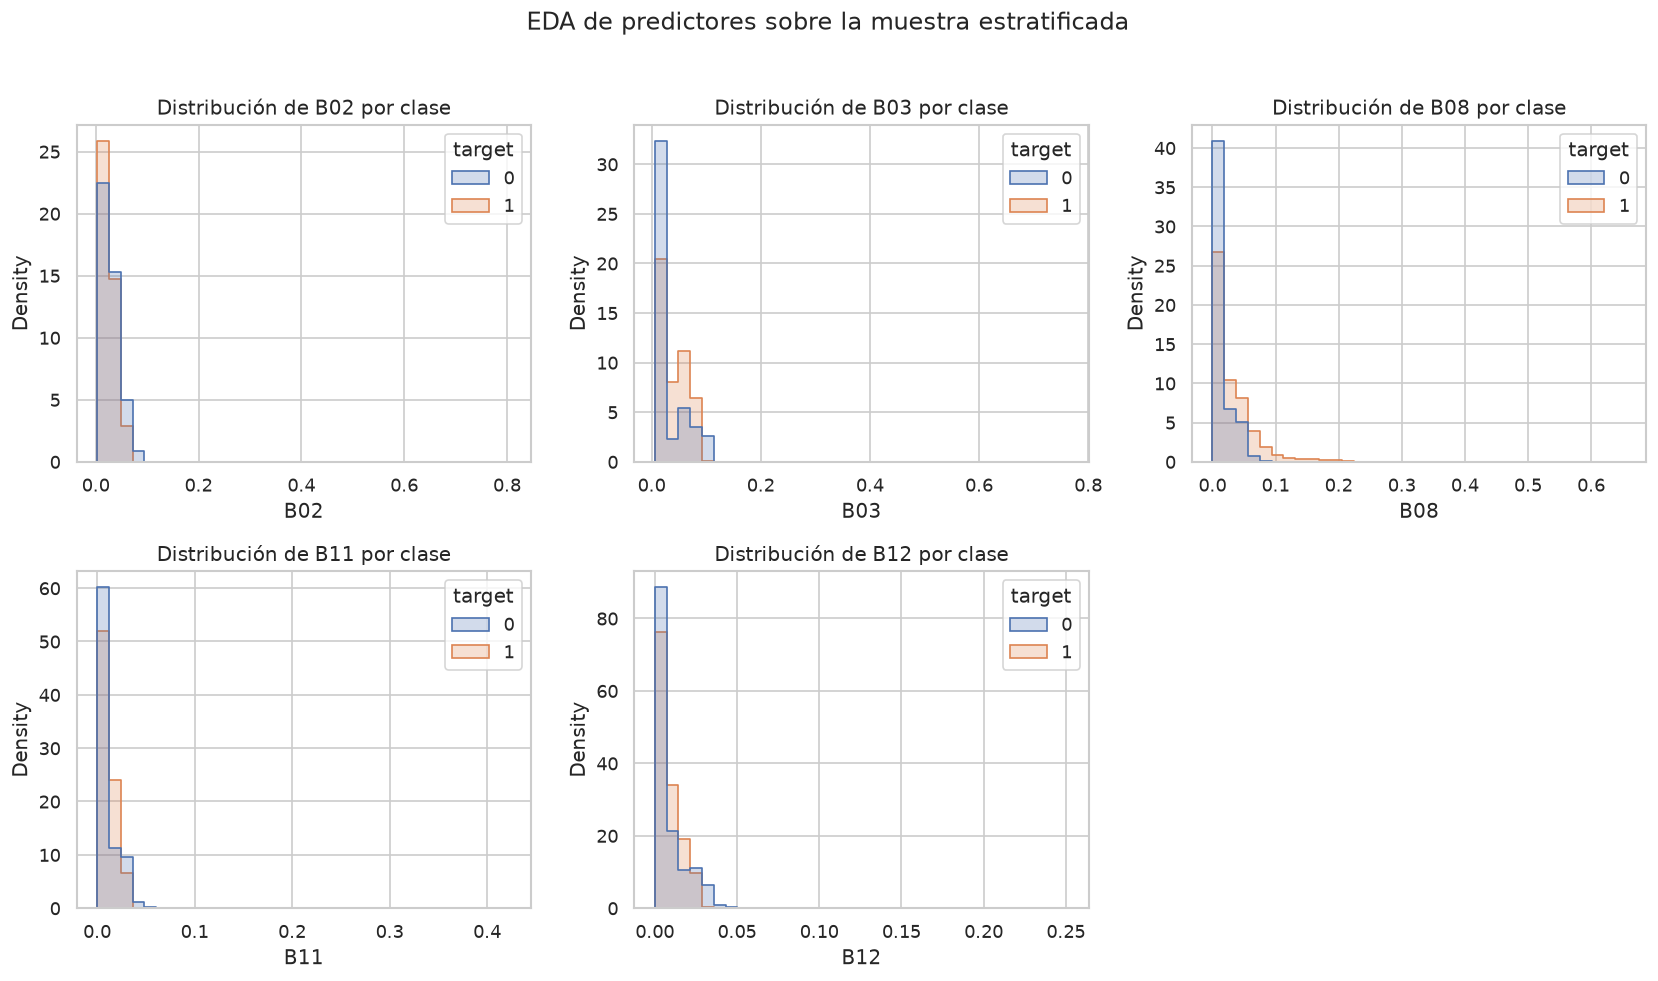

B02             B03             B08             B11  \
                    mean     std    mean     std    mean     std    mean   
lake      target                                                           
amatitlan 0       0.0331  0.0292  0.0495  0.0356  0.0222  0.0235  0.0162   
          1       0.0304  0.0149  0.0519  0.0224  0.0362  0.0313  0.0133   
atitlan   0       0.0228  0.0071  0.0168  0.0059  0.0062  0.0037  0.0045   
          1       0.0166  0.0064  0.0164  0.0106  0.0183  0.0380  0.0047   

                             B12          
                     std    mean     std  
lake      target                          
amatitlan 0       0.0157  0.0141  0.0122  
          1       0.0085  0.0109  0.0074  
atitlan   0       0.0031  0.0039  0.0026  
          1       0.0047  0.0041  0.0037

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for variable, axis in zip(PREDICTORS, axes.flat, strict=False):
    sns.histplot(data=data, x=variable, hue="target", bins=35, stat="density", common_norm=False, element="step", ax=axis)
    axis.set_title(f"Distribución de {variable} por clase")
axes.flat[-1].axis("off")
fig.suptitle("EDA de predictores sobre la muestra estratificada", y=1.02)
plt.tight_layout()
display_figure(fig)

display(data.groupby(["lake", "target"])[list(PREDICTORS)].agg(["mean", "std"]).round(4))

**Interpretación del ejercicio 1.** Los conteos de población, y no la muestra balanceada por estratos, son la referencia para describir cobertura y prevalencia. La muestra solo reduce el costo de entrenamiento. No hay imputación: una observación con predictor no finito queda excluida. La unidad observacional sigue siendo el píxel-fecha; por ello existe dependencia entre píxeles vecinos y entre observaciones repetidas de una zona, problema que se trata explícitamente en las validaciones espacial y temporal.

## Ejercicio 2 — Respuesta binaria, distribución y desbalance

La clase positiva combina dos ramas del algoritmo de origen: proxy NDCI ≥20 y FAI de floración superficial. Este diseño evita convertir la ausencia de una estimación de clorofila en un negativo cuando FAI detecta una capa superficial. El corte es útil como regla de análisis ambiental, pero **no demuestra presencia de una especie, toxicidad ni riesgo sanitario**.

Prevalencia positiva real: 5.04%
Razón mayoría/minoría: 18.85:1


,count
class_0,1952211
class_1,103557


,class_0,class_1,positive_percent
lake,,,
amatitlan,172558,85494,33.1305
atitlan,1779653,18063,1.0048


,lake,date,class_0,class_1,positive_percent
0,amatitlan,2025-01-28,22364,5459,19.6205
1,amatitlan,2025-04-15,10315,1444,12.2800
2,amatitlan,2025-04-28,17782,5450,23.4590
3,amatitlan,2025-11-24,25516,4522,15.0543
4,amatitlan,2026-01-08,18723,12596,40.2184
5,amatitlan,2026-02-02,2577,0,0.0000
6,amatitlan,2026-02-07,8947,128,1.4105
7,amatitlan,2026-03-29,17444,5137,22.7492
8,amatitlan,2026-04-13,27472,7230,20.8345
9,amatitlan,2026-04-28,19302,14160,42.3167


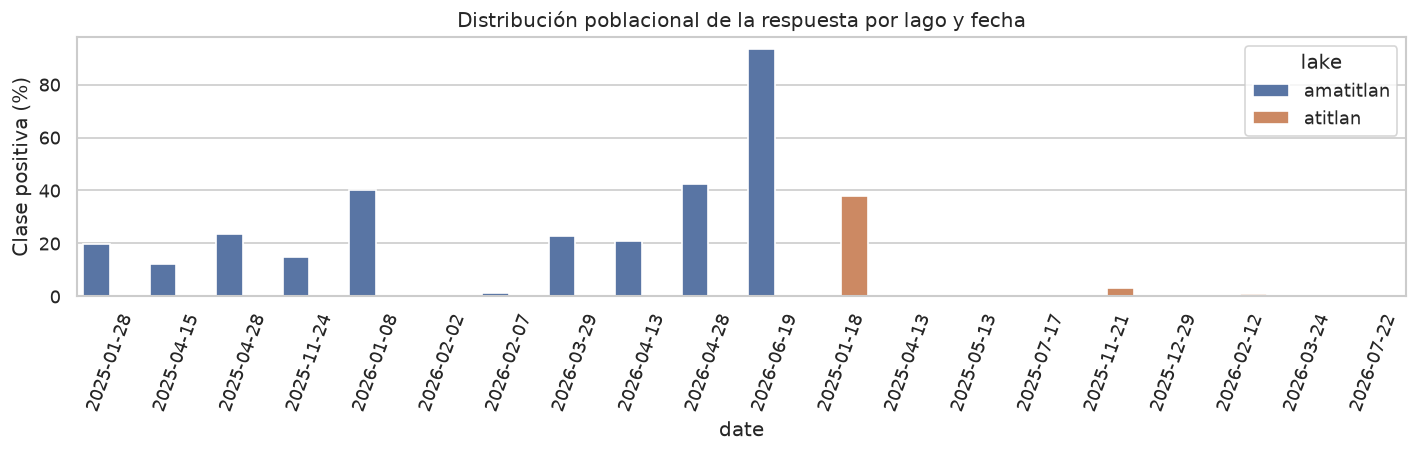

In [5]:
population_distribution = population[["class_0", "class_1"]].sum()
population_prevalence = population_distribution["class_1"] / population_distribution.sum()
distribution_by_lake = population.groupby("lake")[["class_0", "class_1"]].sum()
distribution_by_lake["positive_percent"] = 100 * distribution_by_lake["class_1"] / distribution_by_lake[["class_0", "class_1"]].sum(axis=1)
distribution_by_date = population[["lake", "date", "class_0", "class_1"]].copy()
distribution_by_date["positive_percent"] = 100 * distribution_by_date["class_1"] / distribution_by_date[["class_0", "class_1"]].sum(axis=1)

print(f"Prevalencia positiva real: {population_prevalence:.2%}")
print(f"Razón mayoría/minoría: {population_distribution.max() / population_distribution.min():.2f}:1")
display(population_distribution.to_frame("count"))
display(distribution_by_lake)
display(distribution_by_date)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=distribution_by_date, x="date", y="positive_percent", hue="lake", ax=ax)
ax.tick_params(axis="x", rotation=70)
ax.set_ylabel("Clase positiva (%)")
ax.set_title("Distribución poblacional de la respuesta por lago y fecha")
plt.tight_layout()
display_figure(fig)

**Consecuencia del desbalance.** Accuracy puede parecer alta si un modelo favorece la clase mayoritaria. Por eso se reportan precision, recall, F1 y ROC-AUC, se usan pesos balanceados y se ajustan hiperparámetros con F2, que pondera recall más que precision. Ambientalmente, un falso negativo puede omitir una zona que merece inspección; un falso positivo consume recursos de verificación. Se prioriza reducir falsos negativos sin afirmar que toda señal positiva sea una floración tóxica.

Como el test proviene de la muestra estratificada, precision, accuracy y matrices describen ese diseño de evaluación y no una prevalencia operativa de campo. Para estimar valores predictivos en despliegue sería necesario validar sobre una muestra representativa o recalibrar con la prevalencia poblacional.

**Fuga identificada.** `target`, `cyanobacteria_proxy`, `ndci`, `surface_bloom`, B04/B05 (NDCI), B04/B07/B8A (FAI) y cualquier clase derivada están prohibidos. NDVI también queda fuera porque usa B04. NDWI se conserva, pero se excluye del modelo para mantener un conjunto espectral simple y evitar incorporar un índice ya empleado en la selección de agua.

## Ejercicio 3 — Selección y justificación de variables

In [6]:
variable_catalog = pd.DataFrame([
    ("B02", "Azul", "Banda espectral", "Sí", "Respuesta óptica independiente de NDCI/FAI; puede capturar dispersión y turbidez."),
    ("B03", "Verde", "Banda espectral", "Sí", "Aporta contraste del agua y material suspendido sin formar el target."),
    ("B04", "Rojo", "Banda espectral", "No", "Fuga: participa en NDCI y FAI."),
    ("B05", "Borde rojo 1", "Banda espectral", "No", "Fuga: participa directamente en NDCI."),
    ("B07", "Borde rojo 3", "Banda espectral", "No", "Fuga: participa directamente en FAI."),
    ("B08", "Infrarrojo cercano", "Banda espectral", "Sí", "Describe respuesta del agua/partículas y no forma NDCI ni FAI."),
    ("B8A", "NIR estrecho", "Banda espectral", "No", "Fuga: participa directamente en FAI."),
    ("B11", "SWIR 1", "Banda espectral", "Sí", "Puede capturar humedad y contraste agua-tierra; independiente del target."),
    ("B12", "SWIR 2", "Banda espectral", "Sí", "Complementa discriminación espectral del agua sin formar el target."),
    ("NDVI", "Vegetación", "Índice", "No", "Se conserva por rúbrica, pero usa B04, banda del target."),
    ("NDWI", "Agua", "Índice", "No", "Se conserva para EDA; ya interviene conceptualmente en selección de agua."),
    ("NDCI/proxy/FAI", "Señal objetivo", "Índice/derivada", "No", "Construyen directa o indirectamente la respuesta."),
    ("Longitud/latitud", "Posición", "Espacial", "No", "Se usan para bloques; entrenar con ellas memorizaría zonas."),
    ("Fecha", "Adquisición", "Temporal", "No", "Se usa para corte cronológico; no se codifica para evitar memorizar campañas."),
    ("Lago", "Identidad", "Categórica", "No", "Se conserva para estratos y reporte; podría inflar generalización interna."),
], columns=["variable", "meaning", "class", "used_as_predictor", "justification"])
display(variable_catalog)
print("Predictores finales:", ", ".join(PREDICTORS))

,variable,meaning,class,used_as_predictor,justification
0,B02,Azul,Banda espectral,Sí,Respuesta óptica independiente de NDCI/FAI; pu...
1,B03,Verde,Banda espectral,Sí,Aporta contraste del agua y material suspendid...
2,B04,Rojo,Banda espectral,No,Fuga: participa en NDCI y FAI.
3,B05,Borde rojo 1,Banda espectral,No,Fuga: participa directamente en NDCI.
4,B07,Borde rojo 3,Banda espectral,No,Fuga: participa directamente en FAI.
5,B08,Infrarrojo cercano,Banda espectral,Sí,Describe respuesta del agua/partículas y no fo...
6,B8A,NIR estrecho,Banda espectral,No,Fuga: participa directamente en FAI.
7,B11,SWIR 1,Banda espectral,Sí,Puede capturar humedad y contraste agua-tierra...
8,B12,SWIR 2,Banda espectral,Sí,Complementa discriminación espectral del agua ...
9,NDVI,Vegetación,Índice,No,"Se conserva por rúbrica, pero usa B04, banda d..."


Predictores finales: B02, B03, B08, B11, B12


No se agrega ingeniería de características: cocientes o índices nuevos podrían reconstruir parcialmente la señal objetivo, y con solo 22 fechas aumentarían complejidad sin evidencia independiente. Esta decisión favorece auditabilidad sobre una mejora aparente.

## Ejercicios 4 y 5 — Modelos, ajuste y evaluación aleatoria común

In [7]:
random_train, random_test = random_split_indices(data, random_state=RANDOM_STATE)
models, tuning = tune_models(data, random_train, random_state=RANDOM_STATE)
random_metrics = evaluate_models(models, data, random_test, strategy="random_70_30")

tuning.to_csv(EVIDENCE_DIR / "ml_tuning.csv", index=False)
random_metrics.to_csv(EVIDENCE_DIR / "ml_random_metrics.csv", index=False)

print(f"Train: {len(random_train):,} ({len(random_train)/len(data):.1%}); test común: {len(random_test):,} ({len(random_test)/len(data):.1%})")
display(tuning)
display(random_metrics)

Train: 12,997 (70.0%); test común: 5,571 (30.0%)


,model,best_cv_f2,best_params
0,Logistic regression,0.7143,{'classifier__C': 3.0}
1,Random forest,0.8619,"{'classifier__max_depth': None, 'classifier__m..."
2,Gradient boosting,0.8325,{'classifier__learning_rate': 0.1}


,strategy,model,n_test,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,random_70_30,Logistic regression,5571,0.7421,0.6757,0.7063,0.6906,0.8610,2530,770,667,1604
1,random_70_30,Random forest,5571,0.8718,0.8251,0.8701,0.8470,0.9501,2881,419,295,1976
2,random_70_30,Gradient boosting,5571,0.8397,0.7805,0.8441,0.8111,0.9201,2761,539,354,1917


Los tres modelos usan exactamente el mismo test estratificado 30 %. El ajuste ocurre solo dentro del 70 % de training mediante validación estratificada de tres folds. Se exploran rejillas pequeñas para controlar costo: `C` en logística; profundidad y mínimo por hoja en Random Forest; tasa de aprendizaje en Gradient Boosting. El criterio F2 prioriza sensibilidad sin ignorar precision. Los pesos de clase se calculan únicamente sobre cada training.

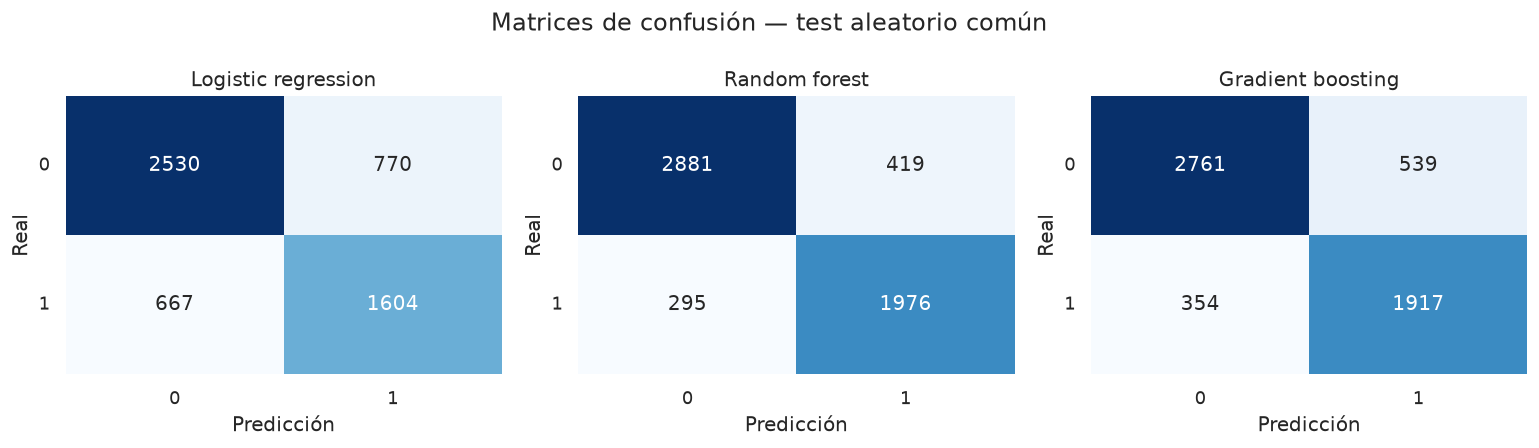

Mayor recall aleatorio: Random forest (0.870); falsos negativos: 295.
La selección ambiental se apoya primero en recall y después en F1; ROC-AUC describe ordenamiento, no el costo operativo del umbral 0.5.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for axis, row in zip(axes, random_metrics.itertuples(), strict=True):
    matrix = np.array([[row.tn, row.fp], [row.fn, row.tp]])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axis)
    axis.set_title(row.model)
    axis.set_xlabel("Predicción")
    axis.set_ylabel("Real")
    axis.set_xticklabels([0, 1])
    axis.set_yticklabels([0, 1], rotation=0)
plt.suptitle("Matrices de confusión — test aleatorio común")
plt.tight_layout()
display_figure(fig)

best_random = random_metrics.sort_values(["recall", "f1"], ascending=False).iloc[0]
print(f"Mayor recall aleatorio: {best_random['model']} ({best_random['recall']:.3f}); falsos negativos: {best_random['fn']}.")
print("La selección ambiental se apoya primero en recall y después en F1; ROC-AUC describe ordenamiento, no el costo operativo del umbral 0.5.")

## Ejercicio 6 — Validación espacial con bloques de 1 km

In [9]:
spatial_data = add_spatial_blocks(data, block_size_m=1_000)
block_counts = spatial_data.groupby(["lake", "spatial_block"], as_index=False).agg(observations=("target", "size"), positives=("target", "sum"), dates=("date", "nunique"))
block_summary = block_counts.groupby("lake").agg(blocks=("spatial_block", "nunique"), min_observations=("observations", "min"), median_observations=("observations", "median"), max_observations=("observations", "max"), total_observations=("observations", "sum"))

block_counts.to_csv(EVIDENCE_DIR / "ml_spatial_block_counts.csv", index=False)
display(block_summary)
display(block_counts)

,blocks,min_observations,median_observations,max_observations,total_observations
lake,,,,,
amatitlan,40,1,192.5,888,10128
atitlan,163,1,53.0,221,8440


,lake,spatial_block,observations,positives,dates
0,amatitlan,amatitlan_757_1601,1,1,1
1,amatitlan,amatitlan_757_1602,95,70,8
2,amatitlan,amatitlan_757_1603,63,55,6
3,amatitlan,amatitlan_758_1601,366,186,9
4,amatitlan,amatitlan_758_1602,601,388,10
...,...,...,...,...,...
198,atitlan,atitlan_702_1621,1,0,1
199,atitlan,atitlan_702_1622,17,4,8
200,atitlan,atitlan_702_1623,19,5,8
201,atitlan,atitlan_702_1624,12,2,7


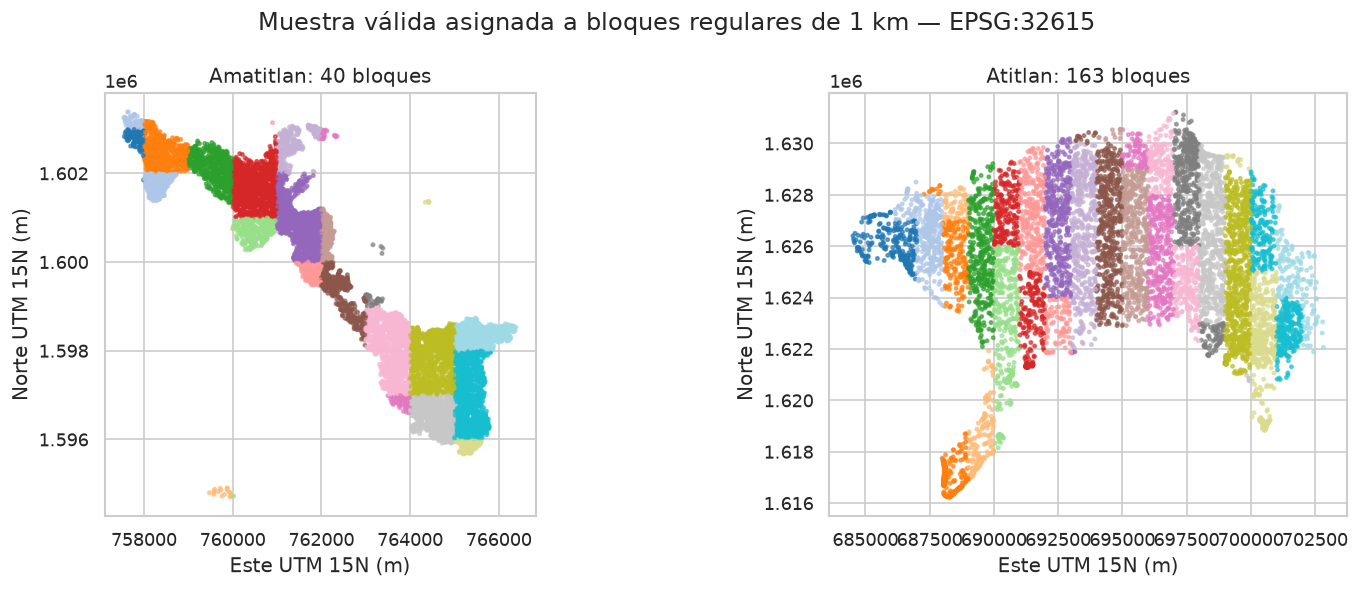

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for axis, (lake, lake_data) in zip(axes, spatial_data.groupby("lake"), strict=True):
    block_codes = pd.Categorical(lake_data["spatial_block"]).codes
    scatter = axis.scatter(lake_data["x_utm"], lake_data["y_utm"], c=block_codes, s=4, cmap="tab20", alpha=0.65)
    axis.set_title(f"{lake.title()}: {lake_data['spatial_block'].nunique()} bloques")
    axis.set_xlabel("Este UTM 15N (m)")
    axis.set_ylabel("Norte UTM 15N (m)")
    axis.set_aspect("equal")
plt.suptitle("Muestra válida asignada a bloques regulares de 1 km — EPSG:32615")
plt.tight_layout()
display_figure(fig)

El tamaño solicitado produce varios grupos con observaciones en ambos lagos y permite cinco folds externos. El identificador incluye lago y celda, por lo que una celda nunca se comparte entre training y validación. La evaluación es **anidada**: para cada test espacial externo se realiza un tuning nuevo dentro del training externo mediante GroupKFold interno de tres folds. Tanto los folds externos como los internos mantienen bloques íntegros; ninguna etiqueta del test externo participa en la selección de hiperparámetros. Si un test fold contiene una sola clase, ROC-AUC se deja como `NaN`; no se inventa un valor.

In [11]:
spatial_folds, spatial_tuning = evaluate_spatial_cv(
    spatial_data, n_splits=5, inner_splits=3, random_state=RANDOM_STATE
)
spatial_folds.to_csv(EVIDENCE_DIR / "ml_spatial_fold_metrics.csv", index=False)
spatial_tuning.to_csv(EVIDENCE_DIR / "ml_spatial_tuning.csv", index=False)
spatial_summary = spatial_folds[spatial_folds["status"] == "ok"].groupby("model", as_index=False)[["accuracy", "precision", "recall", "f1", "roc_auc"]].mean()
display(spatial_folds)
display(spatial_tuning)
display(spatial_summary)
assert spatial_tuning["outer_test_tuning_overlap"].eq(0).all()
assert spatial_tuning["maximum_inner_group_overlap"].eq(0).all()

,strategy,fold,model,n_test,test_classes,status,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,spatial,1,Logistic regression,3714,2,ok,0.7577,0.7614,0.7354,0.7482,0.8745,1477,419,481,1337
1,spatial,1,Random forest,3714,2,ok,0.8487,0.8348,0.8614,0.8479,0.9364,1586,310,252,1566
2,spatial,1,Gradient boosting,3714,2,ok,0.8158,0.7987,0.8339,0.8159,0.8999,1514,382,302,1516
3,spatial,2,Logistic regression,3714,2,ok,0.6793,0.5581,0.6902,0.6172,0.8266,1563,760,431,960
4,spatial,2,Random forest,3714,2,ok,0.8656,0.7710,0.9123,0.8357,0.9539,1946,377,122,1269
5,spatial,2,Gradient boosting,3714,2,ok,0.8363,0.7436,0.8591,0.7972,0.9256,1911,412,196,1195
6,spatial,3,Logistic regression,3714,2,ok,0.7582,0.7226,0.6717,0.6962,0.8618,1787,395,503,1029
7,spatial,3,Random forest,3714,2,ok,0.8549,0.8343,0.8087,0.8213,0.9370,1936,246,293,1239
8,spatial,3,Gradient boosting,3714,2,ok,0.8374,0.8061,0.7977,0.8018,0.9182,1888,294,310,1222
9,spatial,4,Logistic regression,3713,2,ok,0.7681,0.6585,0.7181,0.6870,0.8806,1907,490,371,945


,model,best_inner_f2,best_params,outer_fold,outer_train_n,outer_test_n,outer_test_tuning_overlap,maximum_inner_group_overlap
0,Logistic regression,0.6938,{'classifier__C': 3.0},1,14854,3714,0,0
1,Random forest,0.8292,"{'classifier__max_depth': None, 'classifier__m...",1,14854,3714,0,0
2,Gradient boosting,0.7926,{'classifier__learning_rate': 0.1},1,14854,3714,0,0
3,Logistic regression,0.7294,{'classifier__C': 3.0},2,14854,3714,0,0
4,Random forest,0.8313,"{'classifier__max_depth': None, 'classifier__m...",2,14854,3714,0,0
5,Gradient boosting,0.7946,{'classifier__learning_rate': 0.1},2,14854,3714,0,0
6,Logistic regression,0.7105,{'classifier__C': 3.0},3,14854,3714,0,0
7,Random forest,0.8426,"{'classifier__max_depth': None, 'classifier__m...",3,14854,3714,0,0
8,Gradient boosting,0.8061,{'classifier__learning_rate': 0.1},3,14854,3714,0,0
9,Logistic regression,0.7082,{'classifier__C': 3.0},4,14855,3713,0,0


,model,accuracy,precision,recall,f1,roc_auc
0,Gradient boosting,0.8282,0.7664,0.8329,0.7969,0.9143
1,Logistic regression,0.7440,0.6751,0.7182,0.6941,0.8636
2,Random forest,0.8549,0.7965,0.8664,0.8282,0.9412


## Validación temporal — entrenamiento en pasado, evaluación en futuro

In [12]:
temporal_train, temporal_test, temporal_cutoff = chronological_split_indices(data, train_fraction=0.70)
temporal_metrics, temporal_tuning = evaluate_temporal_holdout(
    data,
    temporal_train,
    temporal_test,
    inner_splits=3,
    random_state=RANDOM_STATE,
)
temporal_metrics.to_csv(EVIDENCE_DIR / "ml_temporal_metrics.csv", index=False)
temporal_tuning.to_csv(EVIDENCE_DIR / "ml_temporal_tuning.csv", index=False)

print(f"Última fecha de training: {pd.Timestamp(data.iloc[temporal_train]['date'].max()).date()}")
print(f"Primera fecha de test: {pd.Timestamp(data.iloc[temporal_test]['date'].min()).date()}")
print(f"Training temporal: {len(temporal_train):,}; test futuro: {len(temporal_test):,}")
print("Fechas de test:", ", ".join(str(pd.Timestamp(value).date()) for value in sorted(data.iloc[temporal_test]['date'].unique())))
display(temporal_metrics)
display(temporal_tuning)
assert temporal_tuning["future_test_tuning_overlap"].eq(0).all()
assert (temporal_tuning["latest_tuning_date"] < temporal_tuning["earliest_future_test_date"]).all()

Última fecha de training: 2026-02-12
Primera fecha de test: 2026-03-24
Training temporal: 12,115; test futuro: 6,453
Fechas de test: 2026-03-24, 2026-03-29, 2026-04-13, 2026-04-28, 2026-06-19, 2026-07-22


,strategy,model,n_test,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,temporal,Logistic regression,6453,0.8872,0.9430,0.7485,0.8345,0.9503,3889,111,617,1836
1,temporal,Random forest,6453,0.8298,0.7627,0.8019,0.7818,0.9231,3388,612,486,1967
2,temporal,Gradient boosting,6453,0.7753,0.6587,0.8488,0.7417,0.8664,2921,1079,371,2082


,model,best_inner_f2,best_params,past_train_n,future_test_n,future_test_tuning_overlap,latest_tuning_date,earliest_future_test_date
0,Logistic regression,0.5740,{'classifier__C': 3.0},12115,6453,0,2026-02-12,2026-03-24
1,Random forest,0.7167,"{'classifier__max_depth': 8, 'classifier__min_...",12115,6453,0,2026-02-12,2026-03-24
2,Gradient boosting,0.7208,{'classifier__learning_rate': 0.05},12115,6453,0,2026-02-12,2026-03-24


El corte se calcula sobre fechas globalmente ordenadas: 70 % de fechas tempranas para training y 30 % posteriores para test. Por construcción, `max(train_date) < min(test_date)`. El tuning temporal también es independiente: usa tres divisiones internas de ventana expansiva dentro del período pasado, y en cada una las fechas de entrenamiento preceden estrictamente a las fechas de validación. Luego se reajusta la mejor configuración sobre todo el pasado y se evalúa una sola vez sobre el futuro. Ni etiquetas ni filas futuras intervienen en la selección.

,model,accuracy,precision,recall,f1,roc_auc,strategy
2,Gradient boosting,0.8397,0.7805,0.8441,0.8111,0.9201,random_70_30
3,Gradient boosting,0.8282,0.7664,0.8329,0.7969,0.9143,spatial_groupkfold
8,Gradient boosting,0.7753,0.6587,0.8488,0.7417,0.8664,temporal_future
0,Logistic regression,0.7421,0.6757,0.7063,0.6906,0.8610,random_70_30
4,Logistic regression,0.7440,0.6751,0.7182,0.6941,0.8636,spatial_groupkfold
6,Logistic regression,0.8872,0.9430,0.7485,0.8345,0.9503,temporal_future
1,Random forest,0.8718,0.8251,0.8701,0.8470,0.9501,random_70_30
5,Random forest,0.8549,0.7965,0.8664,0.8282,0.9412,spatial_groupkfold
7,Random forest,0.8298,0.7627,0.8019,0.7818,0.9231,temporal_future


strategy,random_70_30,spatial_groupkfold,temporal_future,spatial_minus_random,temporal_minus_random
model,,,,,
Gradient boosting,0.8441,0.8329,0.8488,-0.0113,0.0046
Logistic regression,0.7063,0.7182,0.7485,0.0119,0.0422
Random forest,0.8701,0.8664,0.8019,-0.0037,-0.0682


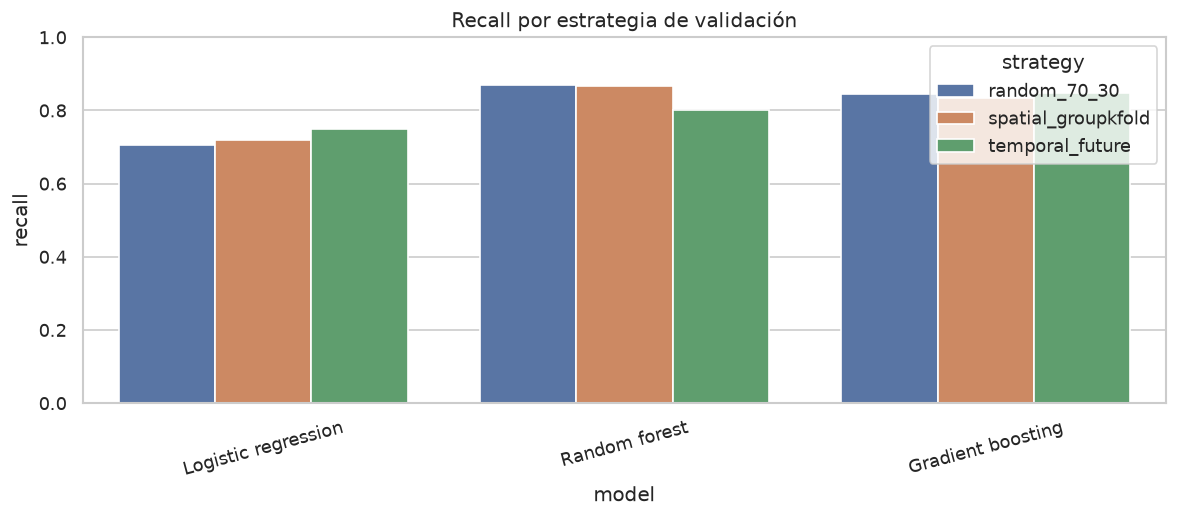

In [13]:
random_comparison = random_metrics[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]].assign(strategy="random_70_30")
spatial_comparison = spatial_summary.assign(strategy="spatial_groupkfold")
temporal_comparison = temporal_metrics[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]].assign(strategy="temporal_future")
comparison = pd.concat([random_comparison, spatial_comparison, temporal_comparison], ignore_index=True)
comparison.to_csv(EVIDENCE_DIR / "ml_validation_comparison.csv", index=False)
display(comparison.sort_values(["model", "strategy"]))

recall_pivot = comparison.pivot(index="model", columns="strategy", values="recall")
recall_pivot["spatial_minus_random"] = recall_pivot["spatial_groupkfold"] - recall_pivot["random_70_30"]
recall_pivot["temporal_minus_random"] = recall_pivot["temporal_future"] - recall_pivot["random_70_30"]
display(recall_pivot)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=comparison, x="model", y="recall", hue="strategy", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Recall por estrategia de validación")
plt.xticks(rotation=15)
plt.tight_layout()
display_figure(fig)

### Interpretación conjunta

La división aleatoria mezcla píxeles vecinos y fechas de una misma escena entre train y test, de modo que puede beneficiarse de autocorrelación y producir una estimación optimista. GroupKFold pregunta si el modelo se desplaza a bloques no vistos, mientras que el corte temporal pregunta si se mantiene en adquisiciones futuras. Las diferencias de recall mostradas arriba cuantifican esa pérdida o ganancia para cada modelo. Con solo 22 escenas, estas métricas tienen incertidumbre y no sustituyen una campaña externa.

El resultado más realista depende del uso: para visitar una nueva zona del mismo sistema, validación espacial; para pronosticar una campaña posterior, validación temporal. Ninguna valida transferencia entre lagos, porque ese experimento pertenece al ejercicio 7 pendiente.

## TODO explícito — trabajo no implementado

Los siguientes ejercicios **no están implementados** en esta entrega parcial:

- **Ejercicio 7 (7.1–7.6), generalización entre lagos:** falta entrenar Atitlán→Amatitlán y Amatitlán→Atitlán, calcular métricas, comparar contra datos mezclados e interpretar diferencias ambientales/espectrales.
- **Ejercicio 8 (8.1–8.4), interpretación:** falta seleccionar el mejor modelo con el conjunto completo de experimentos, producir importancia global y SHAP Summary Plot, e interpretar dirección y contexto ambiental. SHAP no se agregó como dependencia.
- **Ejercicio 9 (9.1–9.7), mapas predictivos:** falta inferir probabilidades sobre las grillas válidas completas, reconstruir y exportar mapas para ambos lagos, comparar con Parte 1 y mapear falsos positivos/negativos y regiones difíciles.
- **Ejercicio 10 (10.1–10.3), análisis y conclusiones finales:** falta integrar los experimentos 7–9, decidir con evidencia si el sistema puede apoyar monitoreo, consolidar limitaciones y proponer datos adicionales.

No se presenta una conclusión final del laboratorio porque hacerlo antes de completar transferencia, explicabilidad y mapas sería científicamente engañoso.